In [1]:
#--1:Most Crowded Route Analysis
#--2:Most Crowded Station Analysis
#--3:Year-wise Passenger Analysis
#--4:Ticket Type Usage Analysis
#--5:Distance vs Fare Relationship
#--6:Most Profitable Route

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("delhi_metro_updated.csv")

In [4]:
print(df)

        TripID        Date         From_Station            To_Station  \
0        59771  2022-05-08             Inderlok         Kashmere Gate   
1        21363  2023-01-12           Model Town        Dilshad Garden   
2       127325  2023-07-13     Kashmere Gate     Netaji Subhash Place   
3       140510  2022-11-10        Chandni Chowk             Hauz Khas   
4       144298  2022-11-06          Rajiv Chowk        Kalkaji Mandir   
...        ...         ...                  ...                   ...   
149995  119880  2022-04-04         KIRTI NAGAR                  AIIMS   
149996  103695  2023-10-25          Model Town               Inderlok   
149997  131933  2023-02-14    Noida City Centre          Shivaji Park   
149998  146868  2024-08-06      Barakhamba Road        Pragati Maidan   
149999  121959  2022-02-11            New Delhi   Central Secretariat   

        Distance_km    Fare  Cost_per_passenger  Passengers   Ticket_Type  \
0             12.94   77.99               18.2

In [5]:
df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak


:-DATA CLEANING AND PROCESSING

In [6]:
#--1:CHECCK THE DATA TYPE.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  object 
 2   From_Station        150000 non-null  object 
 3   To_Station          150000 non-null  object 
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          148500 non-null  float64
 8   Ticket_Type         148500 non-null  object 
 9   Remarks             123743 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 11.4+ MB


In [8]:
#--2:FIND THE MISSING VALUE AND REPLACE WITH SOME VALUES AND LETTER.

In [9]:
df.isnull().sum()

TripID                    0
Date                      0
From_Station              0
To_Station                0
Distance_km               0
Fare                      0
Cost_per_passenger        0
Passengers             1500
Ticket_Type            1500
Remarks               26257
dtype: int64

In [10]:
df['Passengers'] .fillna(df['Passengers'].mean(),inplace=True)
df['Ticket_Type'].fillna('unknown',inplace=True)
df['Remarks'].fillna('No remarks',inplace=True)
print(df.isnull().sum())

TripID                0
Date                  0
From_Station          0
To_Station            0
Distance_km           0
Fare                  0
Cost_per_passenger    0
Passengers            0
Ticket_Type           0
Remarks               0
dtype: int64


C:\Users\Sagar\AppData\Local\Temp\ipykernel_12444\3855802227.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Passengers'] .fillna(df['Passengers'].mean(),inplace=True)
C:\Users\Sagar\AppData\Local\Temp\ipykernel_12444\3855802227.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [11]:
df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,unknown,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak


In [12]:
#--3:FIND THE DUPLICATE VALUES.

In [13]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
149995    False
149996    False
149997    False
149998    False
149999    False
Length: 150000, dtype: bool

In [14]:
#--4:CONVERT THE DTYPE FROM DISTANCE_KM,FARE,COST_PER_PASSENGER,PASSENGERS.

In [15]:
df['Distance_km'] = df['Distance_km'].astype(int)
df['Fare'] = df['Fare'].astype(int)
df['Cost_per_passenger'] = df['Cost_per_passenger'].astype(int)
df['Passengers'] = df['Passengers'].astype(int)

In [16]:
df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12,77,18,13,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2,35,83,15,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5,64,43,9,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4,144,14,27,unknown,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9,104,83,23,Single,off-peak


In [17]:
#--5:CONVERT THE DATE INTO DATETIME.

In [18]:
df['Date']=pd.to_datetime(df['Date'])
df['Date']=df['Date'].dt.year
df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022,Inderlok,Kashmere Gate,12,77,18,13,Smart Card,maintenance
1,21363,2023,Model Town,Dilshad Garden,2,35,83,15,Tourist Card,maintenance
2,127325,2023,Kashmere Gate,Netaji Subhash Place,5,64,43,9,Single,off-peak
3,140510,2022,Chandni Chowk,Hauz Khas,4,144,14,27,unknown,maintenance
4,144298,2022,Rajiv Chowk,Kalkaji Mandir,9,104,83,23,Single,off-peak


:- SHOW THE INSIGHTFUL INFORMATION.

In [19]:
#--1:FIND THE MOST CROWD ROUTES.

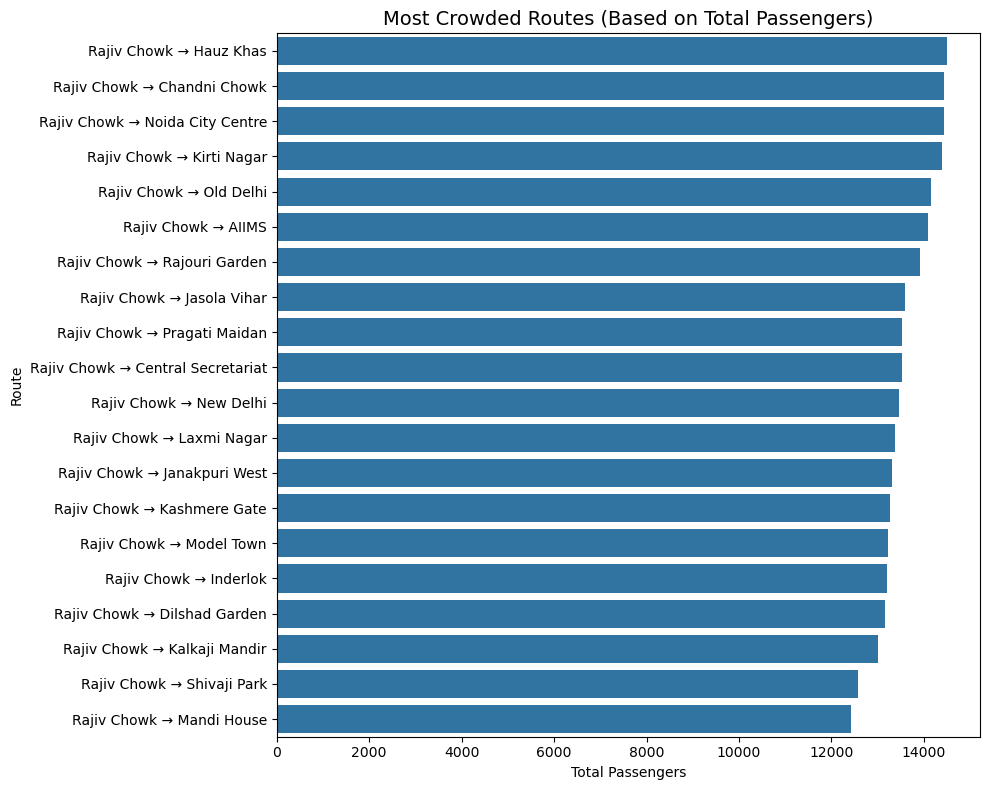

In [20]:
df['Route'] = df['From_Station'] + " → " + df['To_Station']
crowded_route = df.groupby('Route')['Passengers'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=crowded_route.values, y=crowded_route.index)
plt.title("Most Crowded Routes (Based on Total Passengers)", fontsize=14)
plt.xlabel("Total Passengers")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

In [21]:
print("Most crowded route:")
print(crowded_route.head(1))

Most crowded route:
Route
Rajiv Chowk → Hauz Khas    14488
Name: Passengers, dtype: int64


In [22]:
#--2:FIND THE MOST CROWD STATION

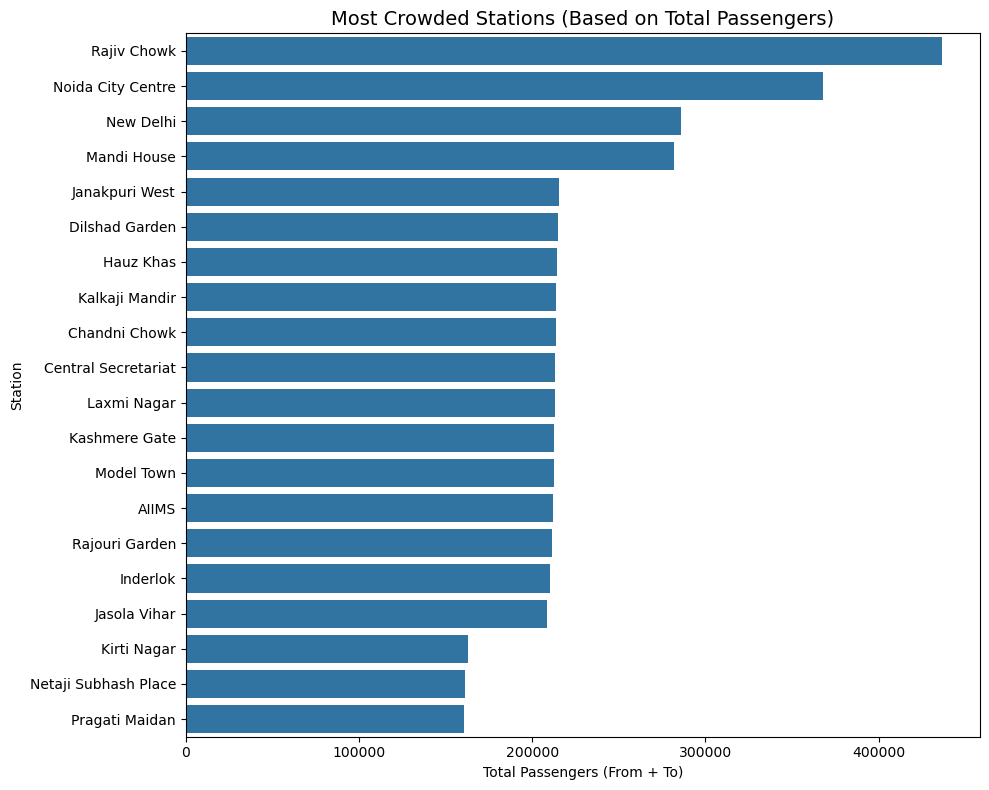

In [23]:
from_counts = df.groupby('From_Station')['Passengers'].sum()
to_counts = df.groupby('To_Station')['Passengers'].sum()
total_counts = from_counts.add(to_counts, fill_value=0).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=total_counts.values, y=total_counts.index)
plt.title("Most Crowded Stations (Based on Total Passengers)", fontsize=14)
plt.xlabel("Total Passengers (From + To)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

In [24]:
print("Most crowded station:")
print(total_counts.head(1))

Most crowded station:
Rajiv Chowk    436680.0
Name: Passengers, dtype: float64


In [25]:
#--3:YEAR WISE PASSENGER 

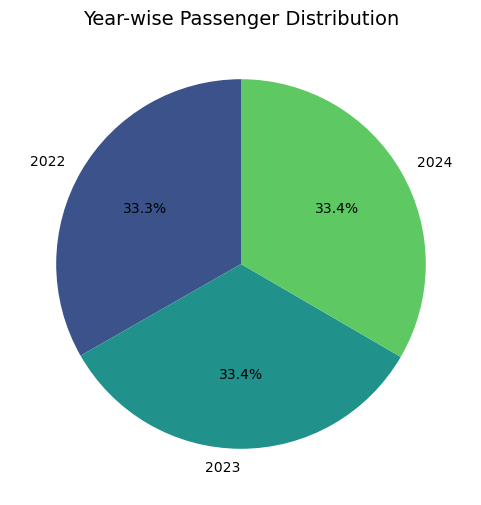

In [26]:
yearly_passengers = df.groupby('Date')['Passengers'].sum()
plt.figure(figsize=(6,6))
colors = sns.color_palette("viridis", len(yearly_passengers))
plt.pie(yearly_passengers, labels=yearly_passengers.index, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title("Year-wise Passenger Distribution", fontsize=14)
plt.show()


In [27]:
print("Year-wise Passenger Count:")
print(yearly_passengers)

Year-wise Passenger Count:
Date
2022     997965
2023    1000747
2024    1001811
Name: Passengers, dtype: int64


In [28]:
#--4:TICKET TYPE USES ANALYSIS

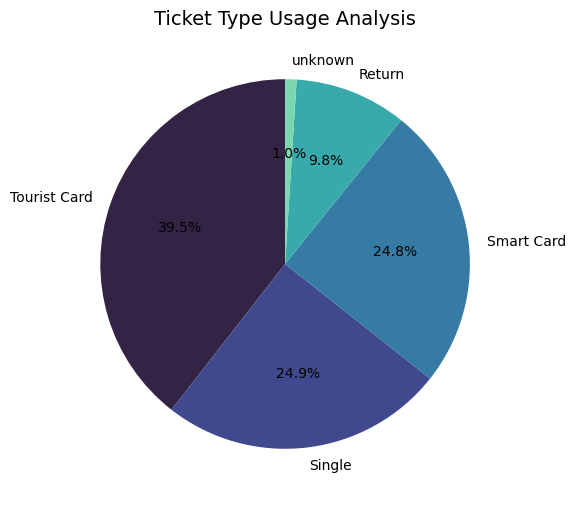

In [29]:
ticket_usage = df.groupby('Ticket_Type')['Passengers'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,6))
colors = sns.color_palette("mako", len(ticket_usage))
plt.pie(ticket_usage, labels=ticket_usage.index, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title("Ticket Type Usage Analysis", fontsize=14)
plt.show()


In [30]:
print("Ticket Type Usage (by total passengers):")
print(ticket_usage)


Ticket Type Usage (by total passengers):
Ticket_Type
Tourist Card    1183860
Single           747171
Smart Card       745489
Return           294084
unknown           29919
Name: Passengers, dtype: int64


In [31]:
#--5:FIND DISTANCE BITWEEN FARE RELATION

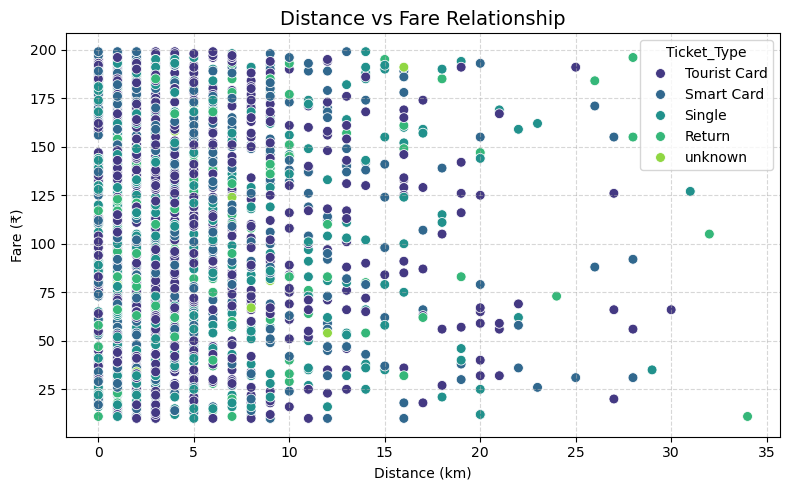

In [32]:
df_sample = df.sample(n=2000, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_sample, x='Distance_km', y='Fare', 
                hue='Ticket_Type', palette='viridis', 
                legend=True, s=50)
plt.title("Distance vs Fare Relationship", fontsize=14)
plt.xlabel("Distance (km)")
plt.ylabel("Fare (₹)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [33]:
print(df[['Distance_km', 'Fare']])

        Distance_km  Fare
0                12    77
1                 2    35
2                 5    64
3                 4   144
4                 9   104
...             ...   ...
149995            5   100
149996            0    86
149997            4   140
149998           12   149
149999            4   171

[150000 rows x 2 columns]


In [34]:
#--6: MOST PROFITABLE ROUTES

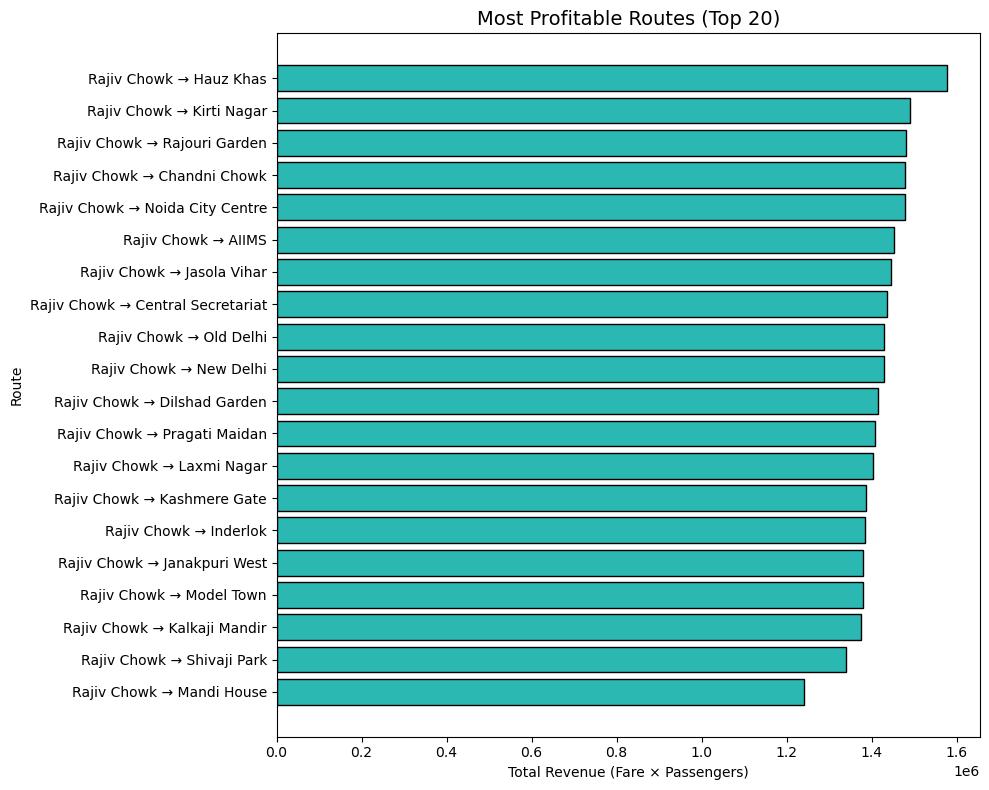

In [35]:
df['Route'] = df['From_Station'] + " → " + df['To_Station']
df['Total_Revenue'] = df['Fare'] * df['Passengers']
route_revenue = df.groupby('Route')['Total_Revenue'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(route_revenue.index, route_revenue.values, color='#2bb8b3', edgecolor='black')
plt.title("Most Profitable Routes (Top 20)", fontsize=14)
plt.xlabel("Total Revenue (Fare × Passengers)")
plt.ylabel("Route")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
print("Most Profitable Route:")
print(route_revenue.head(1))
print("\nAll Route Revenues:\n", route_revenue)


Most Profitable Route:
Route
Rajiv Chowk → Hauz Khas    1576322
Name: Total_Revenue, dtype: int64

All Route Revenues:
 Route
Rajiv Chowk → Hauz Khas              1576322
Rajiv Chowk → Kirti Nagar            1489527
Rajiv Chowk → Rajouri Garden         1481567
Rajiv Chowk → Chandni Chowk          1479677
Rajiv Chowk → Noida City Centre      1478962
Rajiv Chowk → AIIMS                  1453344
Rajiv Chowk → Jasola Vihar           1445628
Rajiv Chowk → Central Secretariat    1436367
Rajiv Chowk → Old Delhi              1430080
Rajiv Chowk → New Delhi              1428818
Rajiv Chowk → Dilshad Garden         1414918
Rajiv Chowk → Pragati Maidan         1407479
Rajiv Chowk → Laxmi Nagar            1404024
Rajiv Chowk → Kashmere Gate          1387996
Rajiv Chowk → Inderlok               1384867
Rajiv Chowk → Janakpuri West         1380508
Rajiv Chowk → Model Town             1378838
Rajiv Chowk → Kalkaji Mandir         1375797
Rajiv Chowk → Shivaji Park           1339915
Rajiv Chowk → Mandi